In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
df = pd.read_csv("georgia1.csv",usecols=['date','COD'])
#导入数据，选取数据中的前两列，分别是日期和COD

FileNotFoundError: [Errno 2] No such file or directory: 'georgia1.csv'

In [9]:
df.head()

NameError: name 'df' is not defined

In [ ]:
df.tail()

,date,COD
889,2022/10/28,3.603
890,2022/10/29,3.540
891,2022/10/30,3.415
892,2022/10/31,6.031
893,2022/11/1,4.961


In [ ]:
# Convert Month into Datetime
df['date']=pd.to_datetime(df['date'])

In [ ]:
df.head()

,date,COD
0,2020-05-18,2.315
1,2020-05-19,6.683
2,2020-05-20,2.121
3,2020-05-21,2.457
4,2020-05-22,2.640


In [ ]:
df.set_index('date',inplace=True)

In [ ]:
df.head()

,COD
date,
2020-05-18,2.315
2020-05-19,6.683
2020-05-20,2.121
2020-05-21,2.457
2020-05-22,2.640


In [ ]:
df.describe()

,COD
count,894.000000
mean,7.087525
std,3.208693
min,0.766000
25%,5.010250
50%,6.609000
75%,8.628500
max,32.162000


<AxesSubplot:xlabel='date'>

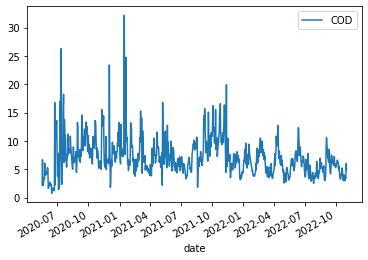

In [ ]:
df.plot()

In [ ]:
from statsmodels.tsa.stattools import adfuller

D:\Anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [ ]:
test_result=adfuller(df['COD'])

In [ ]:
#Ho: It is non stationary
#H1: It is stationary

def adfuller_test(sales):
    result=adfuller(sales)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

In [ ]:
adfuller_test(df['COD'])

ADF Test Statistic : -4.623788224667647
p-value : 0.00011673838030911464
#Lags Used : 12
Number of Observations Used : 881
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


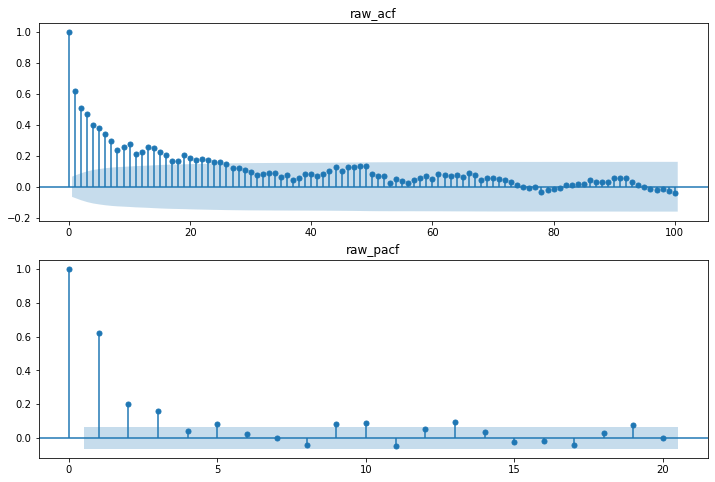

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(2, 1, figsize=(12, 4*2))
# 自相关
plot_acf(df['COD'],lags=100,title='raw_acf', ax=axes[0])  
# 偏自相关
plot_pacf(df['COD'],lags=20,title='raw_pacf', ax=axes[1])  
plt.show()
# 其中lags 表示滞后的阶数，以上分别得到acf 图和pacf 图。

In [3]:
from statsmodels.tsa.arima_model import ARIMA
arima2503 = ARIMA(df["COD"],order=(25,0,3)).fit()
arima2503.summary2()

NameError: name 'df' is not defined

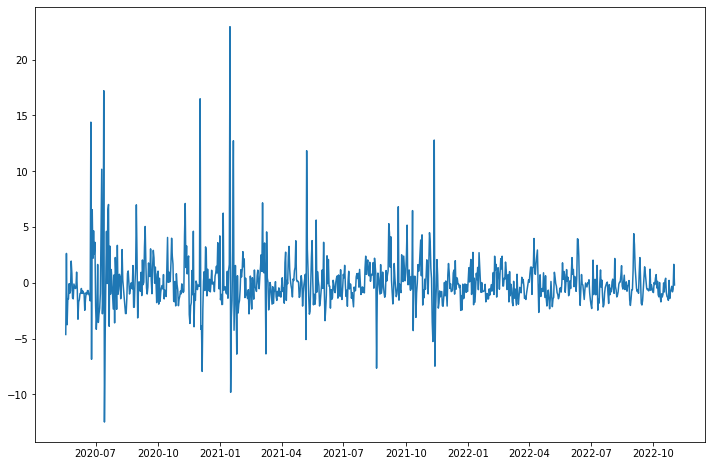

In [ ]:
resid=arima2503.resid  #残差
plt.figure(figsize=(12,8))
plt.plot(resid)

In [ ]:
from scipy import stats
stats.normaltest(resid)#检验序列残差是否为正态分布    pvalue=0.00028625258929196876   <  0.05  拒绝原假设 认为残差符合正太分布

NormaltestResult(statistic=589.5356819410814, pvalue=9.637252192238031e-129)

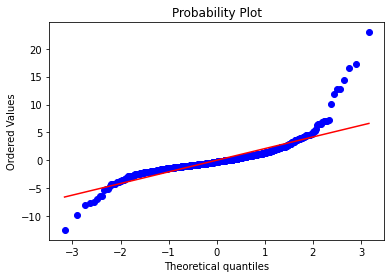

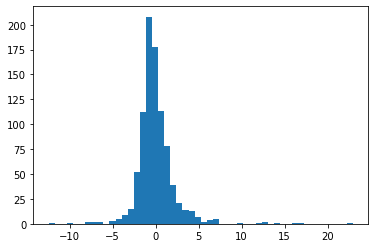

In [ ]:
#p<0.05,接受备择假设，认为残差具有正态性
stats.probplot(resid, dist="norm", plot=plt)
plt.show()
plt.hist(resid,bins=50)
plt.show()

In [ ]:
from statsmodels.stats.stattools import durbin_watson
durbin_watson(arima2503.resid.values)     ##DW检验：靠近2——正常；靠近0——正自相关；靠近4——负自相关

2.0016115434142865

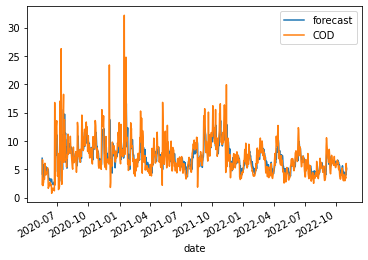

In [ ]:
# 绘制原数据和预测数据对比图
arima2503.plot_predict(dynamic=False)
plt.show()